# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [13]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [14]:
filename = r"C:\DATA 3402\DATA3402.Spring.2026\Labs\Lab.7\SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [15]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [22]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [17]:
Fisher.fit(X_Train,y_Train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


We can plot the output, comparing signal and background:

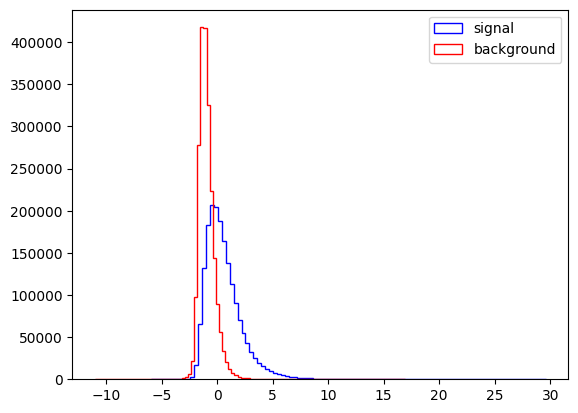

In [18]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

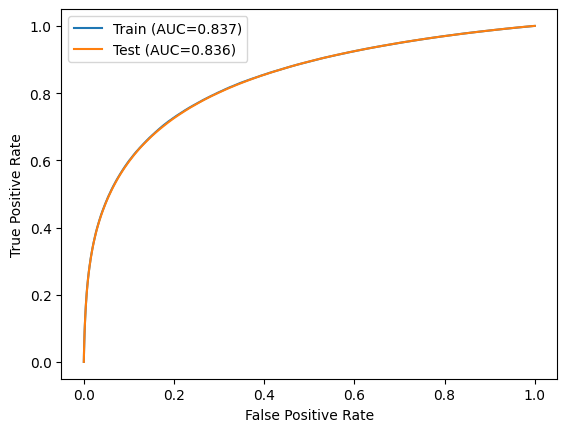

In [19]:
from sklearn.metrics import roc_curve, auc

fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train)) #Compute the AUC for the training set
auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test)) #Compute the AUC for the testing set
auc_test = auc(fpr_test, tpr_test)

plt.figure() # Plot the ROC curve for both training and testing sets
plt.plot(fpr_train, tpr_train, label=f"Train (AUC={auc_train:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test (AUC={auc_test:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
#The lines are similar to each other, which indicates that the model is not overfitting and has good generalization performance on unseen data.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

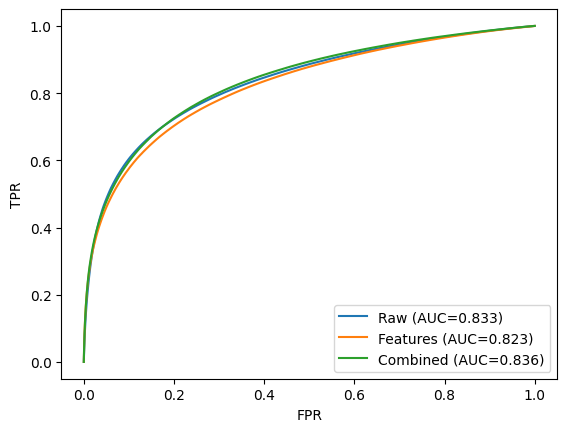

In [20]:
raw_vars = VarNames[1:8] #The first 7 variables are the raw features, and the rest are the engineered features.
feat_vars = VarNames[8:]
all_vars = VarNames[1:]

def compute_roc(vars_used): #Compute the ROC curve and AUC for a given set of variables
    Fisher.fit(X_Train[vars_used], y_Train)
    fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test[vars_used]))
    return fpr, tpr, auc(fpr, tpr)

plt.figure() #Plot the ROC curves for raw features, engineered features, and all features

for label, vars_used in { #A dictionary to label the curves and specify which variables to use for each curve
    "Raw": raw_vars,
    "Features": feat_vars,
    "Combined": all_vars
}.items():
    fpr, tpr, roc_auc = compute_roc(vars_used)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")

plt.legend() #Add a legend to the plot to differentiate between the curves
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()
#The combined features have the highest AUC, which indicates that using both raw and engineered features together provides the best performance for the model. The engineered features alone also perform better than the raw features, suggesting that they capture important information that is not present in the raw features.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

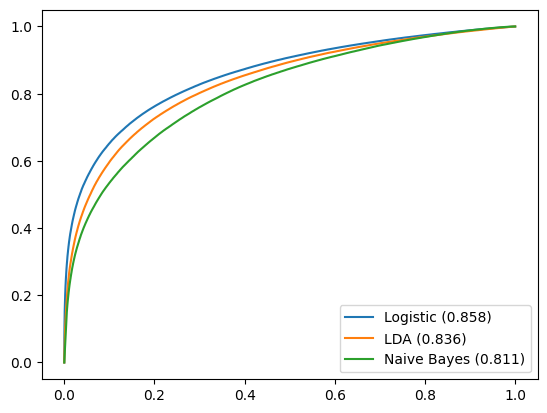

In [23]:
#a Logistic regression, linear discriminant analysis, Gaussian Naive Bayes
#b
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

def evaluate_model(model, vars_used): #Compute the ROC curve and AUC for a given model and set of variables
    model.fit(X_Train[vars_used], y_Train) #Fit the model to the training data using the specified variables
    scores = model.decision_function(X_Test[vars_used]) if hasattr(model, "decision_function") else model.predict_proba(X_Test[vars_used])[:,1]
    
    fpr, tpr, _ = roc_curve(y_Test, scores) #Compute the ROC curve using the true labels and the predicted scores
    return fpr, tpr, auc(fpr, tpr)

models = { #A dictionary to label the models and specify which model to use for each curve
    "Logistic": LogisticRegression(max_iter=500),
    "LDA": LinearDiscriminantAnalysis(),
    "Naive Bayes": GaussianNB()
}

plt.figure() #Plot the ROC curves for the different models using all features

for name, model in models.items(): #Evaluate each model using all features and plot the ROC curve
    fpr, tpr, roc_auc = evaluate_model(model, all_vars)
    plt.plot(fpr, tpr, label=f"{name} ({roc_auc:.3f})")

plt.legend() #Add a legend to the plot to differentiate between the curves
plt.show()

#c
def max_significance(scores, y_true): #Compute the maximum significance (Z) for a given set of predicted scores and true labels
    thresholds = np.linspace(min(scores), max(scores), 100) #Generate 100 thresholds between the minimum and maximum predicted scores
    best_Z = 0
    
    for t in thresholds: #Iterate over each threshold to compute the significance
        S = np.sum((scores > t) & (y_true == 1))
        B = np.sum((scores > t) & (y_true == 0))
        if S + B > 0:
            Z = S / np.sqrt(S + B)
            best_Z = max(best_Z, Z)
    
    return best_Z

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

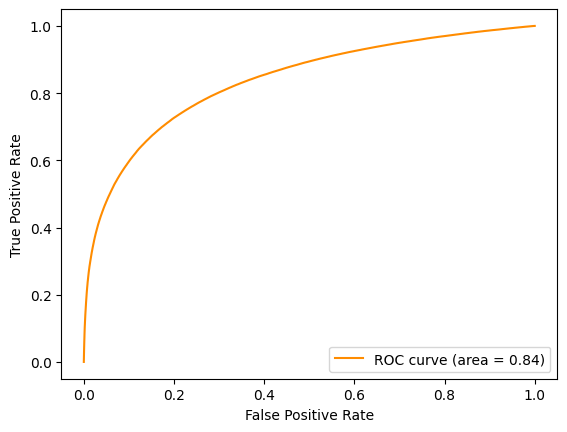

In [24]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [25]:
#b
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

model = LogisticRegression(max_iter=500) #You can choose any of the models (LogisticRegression, RandomForestClassifier, GradientBoostingClassifier) to evaluate the performance metrics. Here, I chose LogisticRegression as an example.
model.fit(X_Train[all_vars], y_Train)

scores = model.predict_proba(X_Test[all_vars])[:,1] #Get the predicted probabilities for the positive class (signal) from the model. This will be used to compute the ROC curve and AUC, as well as to calculate the precision, recall, F1 score, and accuracy based on a threshold of 0.5.
preds = (scores > 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_Test, scores) #Compute the false positive rate (fpr), true positive rate (tpr), and thresholds for the ROC curve using the true labels (y_Test) and the predicted scores (scores).
roc_auc = auc(fpr, tpr)

precision = precision_score(y_Test, preds) #Calculate the precision score, which is the ratio of true positives to the sum of true positives and false positives, using the true labels (y_Test) and the predicted labels (preds).
recall = recall_score(y_Test, preds)
f1 = f1_score(y_Test, preds)
accuracy = accuracy_score(y_Test, preds)

Z = max_significance(scores, y_Test) #Calculate the maximum significance (Z) using the predicted scores and true labels. This will evaluate the performance of the model in terms of its ability to distinguish between signal and background events, which is particularly important in high-energy physics analyses.

table = [ #Create a table to display the performance metrics
    ["AUC", roc_auc],
    ["Precision", precision],
    ["Recall", recall],
    ["F1", f1],
    ["Accuracy", accuracy],
    ["Max Significance", Z]
]

print(tabulate.tabulate(table, headers=["Metric", "Value"])) #Print the table of performance metrics using the tabulate library for better formatting. The headers "Metric" and "Value" will label the columns of the table, and the rows will display the calculated AUC, precision, recall, F1 score, accuracy, and maximum significance for the chosen model.

Metric                 Value
----------------  ----------
AUC                 0.858159
Precision           0.829581
Recall              0.677568
F1                  0.745908
Accuracy            0.788469
Max Significance  516.656
